# Lung Models in Bellows

This notebook demonstrates the lung mechanics available in `bellows`: a linear compliance model, a nonlinear Venegas sigmoid model, and a Venegas model with hysteresis. It also includes an interactive Venegas equation explorer.

Use a kernel where `bellows`, `matplotlib`, and `ipywidgets` are installed. From this repository, `uv sync --dev` will install those development dependencies.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from bellows.simulation.engine import VentilationSimulation
from bellows.simulation.lung_model import LinearLung, VenegasLung, VenegasHysteresisLung
from bellows.simulation.phase import PHASE_EXPIRATION, PHASE_INSPIRATION
from bellows.simulation.runner import run_samples
from bellows.simulation.state import PatientMechanics, VentilatorSettings

## Helpers

In [2]:
def series(samples, attr):
    return [getattr(sample, attr) for sample in samples]


def simulate(settings, lung_model, *, resistance=10.0, seconds=12.0, dt_s=0.01):
    patient = PatientMechanics(
        lung_model=lung_model,
        resistance_cm_h2o_s_per_l=resistance,
    )
    simulation = VentilationSimulation(settings=settings, patient=patient)
    samples = run_samples(simulation, seconds=seconds, dt_s=dt_s)
    return simulation, samples


def last_breath(samples):
    breaths = sorted({sample.breath for sample in samples}, reverse=True)
    for breath in breaths:
        breath_samples = [sample for sample in samples if sample.breath == breath]
        phases = {sample.phase for sample in breath_samples}
        if {"inspiration", "expiration"}.issubset(phases):
            return breath_samples
    raise ValueError("No complete breath with inspiration and expiration samples")


def venegas_volume(pressure, *, inflection, slope_width, recruitable_volume, residual_volume):
    return residual_volume + recruitable_volume / (1.0 + np.exp(-(pressure - inflection) / slope_width))

## Static Pressure-Volume Relationships

`LinearLung` has constant compliance. `VenegasLung` has a sigmoid pressure-volume relationship, so compliance changes with pressure. `VenegasHysteresisLung` shifts the inflation and deflation limbs apart.

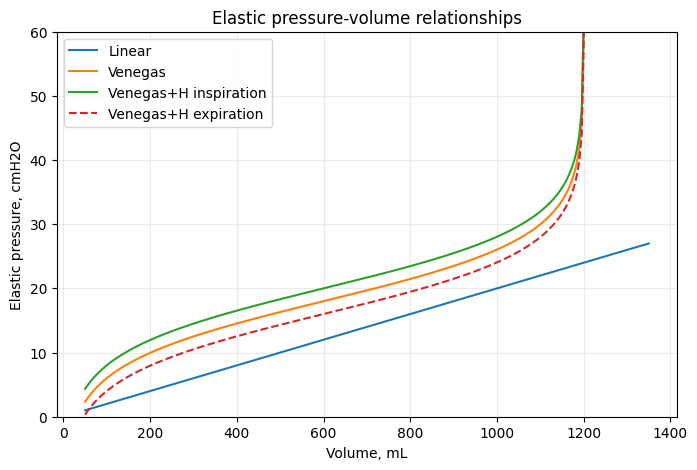

In [3]:
volumes_l = np.linspace(0.05, 1.35, 220)
volumes_ml = volumes_l * 1000

linear = LinearLung(compliance_l_per_cm_h2o=0.05)
venegas = VenegasLung(inflection_cm_h2o=18.0, slope_width_cm_h2o=5.0, recruitable_volume_l=1.2)
hysteresis = VenegasHysteresisLung(
    inflection_cm_h2o=18.0,
    slope_width_cm_h2o=5.0,
    recruitable_volume_l=1.2,
    hysteresis_offset_cm_h2o=4.0,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(volumes_ml, [linear.elastic_pressure(v, PHASE_INSPIRATION) for v in volumes_l], label="Linear")
ax.plot(volumes_ml, [venegas.elastic_pressure(v, PHASE_INSPIRATION) for v in volumes_l], label="Venegas")
ax.plot(
    volumes_ml,
    [hysteresis.elastic_pressure(v, PHASE_INSPIRATION) for v in volumes_l],
    label="Venegas+H inspiration",
)
ax.plot(
    volumes_ml,
    [hysteresis.elastic_pressure(v, PHASE_EXPIRATION) for v in volumes_l],
    linestyle="--",
    label="Venegas+H expiration",
)
ax.set_xlabel("Volume, mL")
ax.set_ylabel("Elastic pressure, cmH2O")
ax.set_title("Elastic pressure-volume relationships")
ax.set_ylim(0, 60)
ax.legend()
ax.grid(True, alpha=0.25);

## Same Ventilator Settings, Different Lung Models

The same pressure-control settings produce different volume responses depending on the lung model and where the lung is operating on its pressure-volume curve.

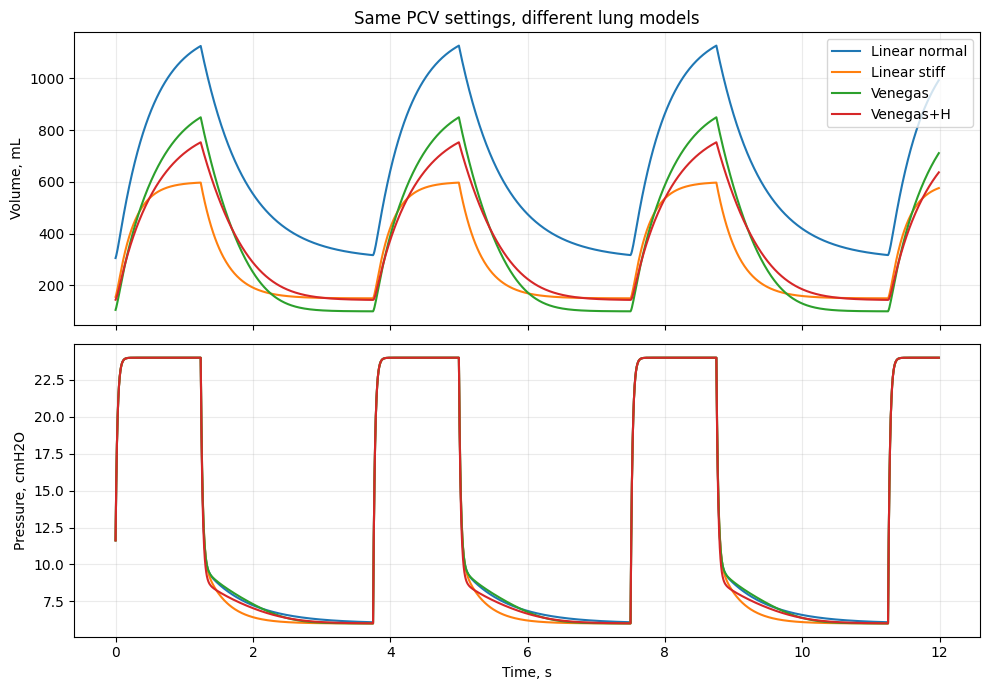

In [4]:
settings = VentilatorSettings(
    mode="PCV",
    rr_bpm=16.0,
    pinsp_cm_h2o=18.0,
    peep_cm_h2o=6.0,
    ie_i=1.0,
    ie_e=2.0,
)

cases = {
    "Linear normal": LinearLung(0.05),
    "Linear stiff": LinearLung(0.025),
    "Venegas": VenegasLung(inflection_cm_h2o=18.0, slope_width_cm_h2o=5.0, recruitable_volume_l=1.2),
    "Venegas+H": VenegasHysteresisLung(
        inflection_cm_h2o=18.0,
        slope_width_cm_h2o=5.0,
        recruitable_volume_l=1.2,
        hysteresis_offset_cm_h2o=4.0,
    ),
}

results = {name: simulate(settings, lung_model) for name, lung_model in cases.items()}

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 7))
for name, (_simulation, samples) in results.items():
    axes[0].plot(series(samples, "time_s"), series(samples, "volume_ml"), label=name)
    axes[1].plot(series(samples, "time_s"), series(samples, "pressure_cm_h2o"), label=name)

axes[0].set_ylabel("Volume, mL")
axes[1].set_ylabel("Pressure, cmH2O")
axes[1].set_xlabel("Time, s")
axes[0].set_title("Same PCV settings, different lung models")
axes[0].legend()
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.tight_layout();

## Airway PV Loops from the Simulation

These loops plot simulated airway pressure against simulated lung volume for the last completed breath. The hysteresis model separates the inflation and deflation elastic curves, while circuit resistance and valve behavior shape the airway pressure seen during flow.

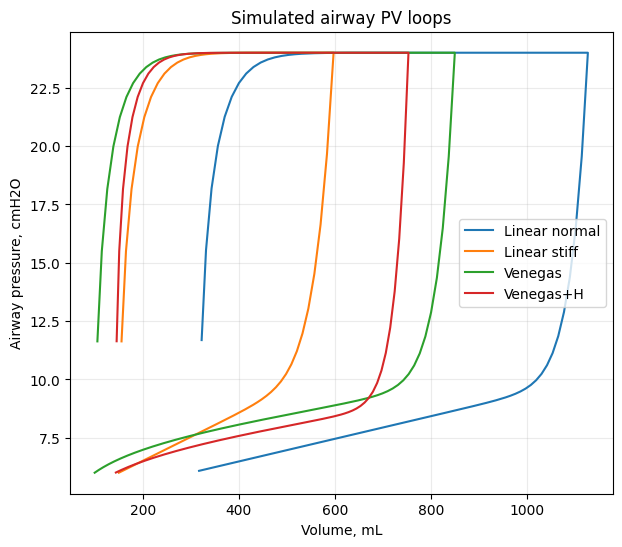

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, (_simulation, samples) in results.items():
    breath = last_breath(samples)
    ax.plot(series(breath, "volume_ml"), series(breath, "pressure_cm_h2o"), label=name)

ax.set_xlabel("Volume, mL")
ax.set_ylabel("Airway pressure, cmH2O")
ax.set_title("Simulated airway PV loops")
ax.legend()
ax.grid(True, alpha=0.25);

## Interactive Venegas Equation Explorer

The Venegas equation is:

`V(P) = residual_volume + recruitable_volume / (1 + exp(-(P - inflection) / slope_width))`

Move the sliders to see how each parameter changes the pressure-volume curve.

In [6]:
pressure = np.linspace(0.0, 45.0, 300)


@widgets.interact(
    inflection=widgets.FloatSlider(value=18.0, min=5.0, max=35.0, step=1.0, description="inflection"),
    slope_width=widgets.FloatSlider(value=5.0, min=1.0, max=12.0, step=0.5, description="slope width"),
    recruitable_volume=widgets.FloatSlider(value=1.2, min=0.3, max=2.5, step=0.1, description="recruitable"),
    residual_volume=widgets.FloatSlider(value=0.0, min=0.0, max=0.6, step=0.05, description="residual"),
)
def plot_venegas_equation(inflection, slope_width, recruitable_volume, residual_volume):
    volume_l = venegas_volume(
        pressure,
        inflection=inflection,
        slope_width=slope_width,
        recruitable_volume=recruitable_volume,
        residual_volume=residual_volume,
    )
    compliance_l_per_cm_h2o = (
        recruitable_volume / slope_width
        * ((volume_l - residual_volume) / recruitable_volume)
        * (1.0 - (volume_l - residual_volume) / recruitable_volume)
    )

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(pressure, volume_l * 1000, color="tab:green")
    axes[0].axvline(inflection, color="0.5", linestyle="--", label="inflection")
    axes[0].set_xlabel("Pressure, cmH2O")
    axes[0].set_ylabel("Volume, mL")
    axes[0].set_title("Venegas pressure-volume curve")
    axes[0].set_ylim(0, 3000)
    axes[0].legend()

    axes[1].plot(pressure, compliance_l_per_cm_h2o * 1000, color="tab:purple")
    axes[1].axvline(inflection, color="0.5", linestyle="--")
    axes[1].set_xlabel("Pressure, cmH2O")
    axes[1].set_ylabel("Local compliance, mL/cmH2O")
    axes[1].set_title("Compliance peaks near inflection")
    axes[1].set_ylim(0, 160)

    for ax in axes:
        ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=18.0, description='inflection', max=35.0, min=5.0, step=1.0), FloatSli…

Parameter intuition:

- `inflection`: shifts the recruitable part of the curve left or right along the pressure axis.
- `slope_width`: controls how broad the recruitment transition is. Smaller values make a steeper transition.
- `recruitable_volume`: changes the vertical span between lower and upper asymptotes.
- `residual_volume`: raises the lower asymptote.